<a href="https://colab.research.google.com/github/ViKing-Coder-jpg/CryptoMoon/blob/main/BackEnd/CryptoMoon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CryptoMoon -A Bitcoin Predictor


# Data Extraction and Library Importing

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error,mean_absolute_error

In [26]:
import kagglehub
path = kagglehub.dataset_download("aiwithcagri/bitcoin-12-years-price-january-2026")
data= pd.read_csv(path+'/bitcoin (1).csv')
data.shape

Using Colab cache for faster access to the 'bitcoin-12-years-price-january-2026' dataset.


(4134, 6)

#Data Cleaning and Preprocessing

In [27]:
print('Empty Cells:',data.isna().sum().sum())
data['Date']=pd.to_datetime(data['Date'])
data.sort_values('Date',inplace=True)
data['Close'].median()


Empty Cells: 0


10795.1455078125

#Feature Engineering and train-test splitting

In [28]:

featData=pd.DataFrame()
featData['Close']=data['Close']

featData['SMA_20']=data['Close'].rolling(window=20).mean()
featData['SMA_20_y']=featData['SMA_20'].shift(1)
featData['SMA_50']=data['Close'].rolling(window=50).mean()
featData['SMA_50_y']=featData['SMA_50'].shift(1)

featData['EMA_12'] = data['Close'].ewm(span=12, adjust=False).mean()
featData['EMA_26'] = data['Close'].ewm(span=26, adjust=False).mean()
featData['MACD'] = featData['EMA_12'] - featData['EMA_26']

delta = data['Close'].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
avg_gain = gain.ewm(span=14, adjust=False).mean()
avg_loss = loss.ewm(span=14, adjust=False).mean()
rs = avg_gain / (avg_loss + 1e-9)
featData['RSI'] = 100 - (100 / (1 + rs))

featData['Returns']=data['Close'].pct_change()
featData['Close_SMA20_Ratio']=data['Close']/featData['SMA_20'].shift(1)
featData['Close_SMA50_Ratio']=data['Close']/featData['SMA_50'].shift(1)
featData['SMA_Cross']=np.where(((featData['SMA_20']>featData['SMA_50'])& (featData['SMA_20_y']<=featData['SMA_50_y'])),1,np.where(((featData['SMA_20']<featData['SMA_50'])& (featData['SMA_20_y']>featData['SMA_50_y'])),-1,0))
featData['MACD_signal']=featData['MACD'].ewm(span=9, adjust=False).mean()
featData['MACD_histogram']=featData['MACD']-featData['MACD_signal']
featData['RSI_signal']=np.where(featData['RSI']>70,1,np.where(featData['RSI']<30,-1,0))
featData['Volume_change']=data['Volume'].pct_change()
featData['Volume_SMA_20'] = data['Volume'].rolling(window=20).mean()
featData['Volume_SMA_20_Ratio'] = data['Volume'] / featData['Volume_SMA_20'].shift(1)
featData['Lag_1']=featData['Returns'].shift(1)
featData['Lag_2']=featData['Returns'].shift(2)
featData['Lag_3']=featData['Returns'].shift(3)
featData['Lag_5']=featData['Returns'].shift(5)
featData['Lag_7']=featData['Returns'].shift(7)
featData['Volatility_5']=featData['Returns'].rolling(window=5).std()
featData['Volatility_10']=featData['Returns'].rolling(window=10).std()
featData['HL_Range_pct'] = (data['High'] - data['Low']) / data['Close']
featData['OC_Range_pct'] = (data['Close'] - data['Open']) / data['Open']
featData['EMA_20'] = data['Close'].ewm(span=20, adjust=False).mean()
featData['Close_EMA20_diff'] = (data['Close'] - featData['EMA_20']) / data['Close']

featData['Target'] = featData['Returns'].shift(-1)
featData.dropna(inplace=True)
featData.reset_index(drop=True,inplace=True)
# print(featData['Target'].describe())
# print(featData[['Close', 'Target']].head(10))
featData.drop(['SMA_20','SMA_50','SMA_20_y','SMA_50_y','EMA_12','EMA_20','EMA_26','Close','MACD_signal','RSI_signal','SMA_Cross','Volume_SMA_20'],axis=1,inplace=True)



In [29]:

y=featData['Target']
X=featData.drop('Target',axis=1)


In [30]:
print(X.columns.tolist())


['MACD', 'RSI', 'Returns', 'Close_SMA20_Ratio', 'Close_SMA50_Ratio', 'MACD_histogram', 'Volume_change', 'Volume_SMA_20_Ratio', 'Lag_1', 'Lag_2', 'Lag_3', 'Lag_5', 'Lag_7', 'Volatility_5', 'Volatility_10', 'HL_Range_pct', 'OC_Range_pct', 'Close_EMA20_diff']


In [31]:
# Calculate the split point (80% for training, 20% for testing)
split_point = int(len(X) * 0.8)

# Split the data chronologically
X_train = X.iloc[:split_point]
X_test = X.iloc[split_point:]
y_train = y.iloc[:split_point]
y_test = y.iloc[split_point:]



# Model Training and Testing
  Using XGBoost as Base ML Model



In [32]:
model=XGBRegressor(
     n_estimators=1000,
    learning_rate=0.02,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:pseudohubererror'
)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)


In [33]:
threshold = 0.008

signals = np.where(y_pred > threshold, 1,
          np.where(y_pred < -threshold, -1, 0))

mask = signals != 0

direction_acc = np.mean((signals[mask] > 0) == (y_test[mask] > 0))

print("Filtered Accuracy:", direction_acc)
print("Trade %:", np.mean(mask))

Filtered Accuracy: 0.5424836601307189
Trade %: 0.18727050183598531


In [34]:
print('r2_score',r2_score(y_test,y_pred))
print('mean_squared_error',mean_squared_error(y_test,y_pred))
print('root_mean_squared_error',root_mean_squared_error(y_test,y_pred))

r2_score -0.021106413343589425
mean_squared_error 0.0006359281321722001
root_mean_squared_error 0.02521761551321219


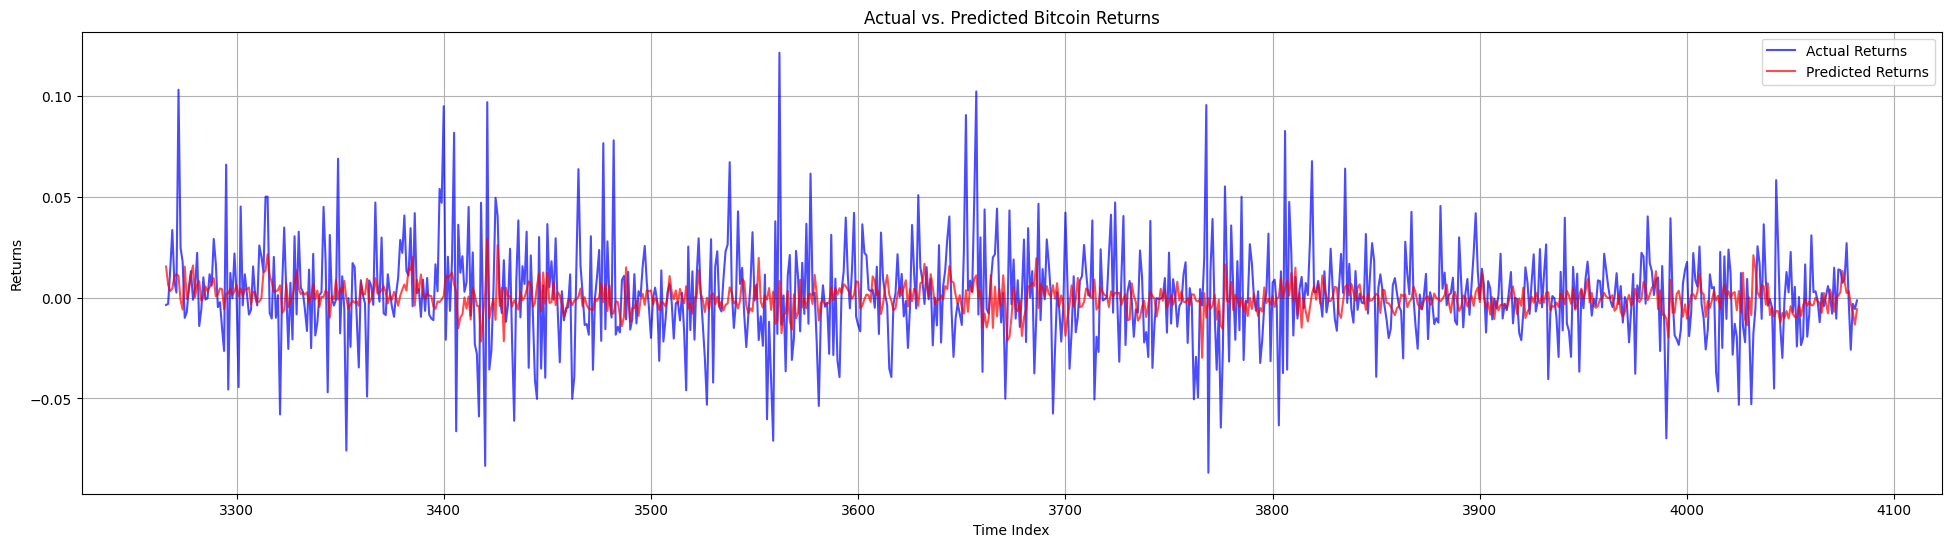

In [35]:
plt.figure(figsize=(24, 6))
plt.plot(y_test.index, y_test, label='Actual Returns', color='blue', alpha=0.7)
plt.plot(y_test.index, y_pred, label='Predicted Returns', color='red', alpha=0.7)
plt.title('Actual vs. Predicted Bitcoin Returns')
plt.xlabel('Time Index')
plt.ylabel('Returns')
plt.legend()
plt.grid(True)
plt.show()

Best Threshold: 0.0029473684210526317
Best Return: 2.0489762108502783


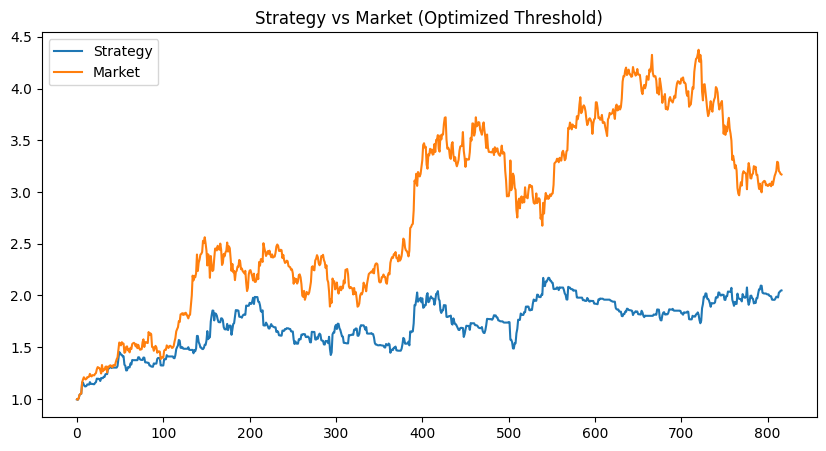

In [40]:
thresholds = np.linspace(0.002, 0.02, 20)

best_return = -np.inf
best_threshold = None

for t in thresholds:
    signals = np.where(y_pred > t, 1,
              np.where(y_pred < -t, -1, 0))

    position = signals
    strategy_returns = position * y_test.values

    # transaction cost
    cost = 0.001
    trades = np.abs(np.diff(position, prepend=0))
    strategy_returns = strategy_returns - cost * trades

    cumulative = (1 + strategy_returns).cumprod()
    final_return = cumulative[-1]

    if final_return > best_return:
        best_return = final_return
        best_threshold = t

print("Best Threshold:", best_threshold)
print("Best Return:", best_return)

# -------------------------------
# 5. FINAL STRATEGY WITH BEST THRESHOLD
# -------------------------------

signals = np.where(y_pred > best_threshold, 1,
          np.where(y_pred < -best_threshold, -1, 0))

position = signals
strategy_returns = position * y_test.values

# transaction cost
cost = 0.001
trades = np.abs(np.diff(position, prepend=0))
strategy_returns = strategy_returns - cost * trades

# cumulative
cumulative_strategy = (1 + strategy_returns).cumprod()
cumulative_market = (1 + y_test.values).cumprod()

# -------------------------------
# 6. PLOT
# -------------------------------

plt.figure(figsize=(10,5))
plt.plot(cumulative_strategy, label="Strategy")
plt.plot(cumulative_market, label="Market")
plt.legend()
plt.title("Strategy vs Market (Optimized Threshold)")
plt.show()

Sharpe Ratio: 0.832
Max Drawdown: -38.44%
Final Strategy Return: 1.730x
Final Market Return: 3.169x


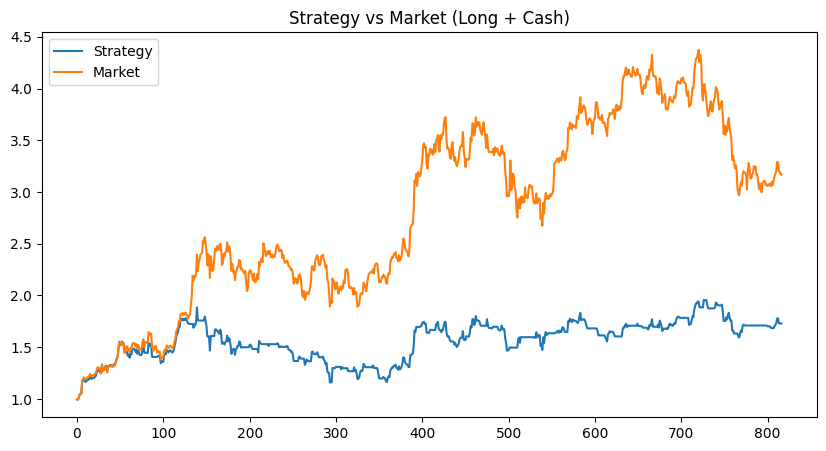

In [42]:
# Long + Cash strategy (no shorting)
# Only exit to cash when model is confident of a down move
# Otherwise stay in market (default bias = long)

threshold_enter = 0.002   # enter/stay long if pred > this
threshold_exit = -0.005   # exit to cash only if pred < this (high confidence down)
                          # between the two = hold current position

position = np.zeros(len(y_pred))
current_pos = 1  # start invested

for i in range(len(y_pred)):
    if y_pred[i] > threshold_enter:
        current_pos = 1   # go/stay long
    elif y_pred[i] < threshold_exit:
        current_pos = 0   # exit to cash
    # else: hold current position (no flip-flopping)
    position[i] = current_pos

# Apply returns
strategy_returns = position * y_test.values

# Transaction cost only when position changes
trades = np.abs(np.diff(position, prepend=0))
cost = 0.001
strategy_returns = strategy_returns - cost * trades

# Cumulative
cumulative_strategy = (1 + strategy_returns).cumprod()
cumulative_market = (1 + y_test.values).cumprod()

# Metrics
sharpe = (strategy_returns.mean() / strategy_returns.std()) * np.sqrt(365)
drawdown = (cumulative_strategy / np.maximum.accumulate(cumulative_strategy) - 1).min()

print(f"Sharpe Ratio: {sharpe:.3f}")
print(f"Max Drawdown: {drawdown:.2%}")
print(f"Final Strategy Return: {cumulative_strategy[-1]:.3f}x")
print(f"Final Market Return: {cumulative_market[-1]:.3f}x")

# Plot
plt.figure(figsize=(10,5))
plt.plot(cumulative_strategy, label='Strategy')
plt.plot(cumulative_market, label='Market')
plt.legend()
plt.title('Strategy vs Market (Long + Cash)')
plt.show()